In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

import re
import os

In [2]:
# Data
data_path = os.path.join("..", "data", "IPL Auction (2013-2026).xlsx")
data = pd.read_excel(data_path)

data.head()

,Team,Player,Role,Value,Year
0,Chennai Super Kings,Christopher Morris,All-Rounder,625000,2013
1,Chennai Super Kings,Dirk Nannes,Bowler,600000,2013
2,Chennai Super Kings,Ben Laughlin,Bowler,20000,2013
3,Chennai Super Kings,Akila Dananjaya,All-Rounder,20000,2013
4,Chennai Super Kings,Jason Holder,Bowler,20000,2013


In [3]:
data["Value"] = data["Value"].apply(lambda x: float(re.sub(r"[?,/]", "", x)) if isinstance(x, str) else float(x))

In [4]:
df = data.copy()

In [5]:
year_start = 2013

df2 = df[df["Year"]>=year_start]

In [6]:
# ----------------------------
# Inputs
# ----------------------------
df = df2.copy()  # your dataset
year_col = "Year"
value_col = "Value"

# ----------------------------
# 1) Year-wise metrics (actuals)
# ----------------------------
df_year = (
    df.groupby(year_col, as_index=False)
      .agg(
          total_spent=(value_col, "sum"),
          max_spent=(value_col, "max"),
          n_players=(value_col, "size"),
      )
      .sort_values(year_col)
      .reset_index(drop=True)
)

# ----------------------------
# 2) Spline smoothing helper
# ----------------------------
def spline_smooth(x, y, n_points=400, k=3):
    """
    x: 1D array-like, strictly increasing
    y: 1D array-like
    n_points: number of points in smooth curve
    k: spline degree (3 = cubic). If too few points, it auto-reduces.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Need at least (k+1) points; reduce k if needed
    k_eff = min(k, max(1, len(x) - 1))

    x_smooth = np.linspace(x.min(), x.max(), n_points)
    spline = make_interp_spline(x, y, k=k_eff)
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth

# ----------------------------
# 3) Prepare x/y and smooth
# ----------------------------
years = df_year[year_col].to_numpy(dtype=float)

total_spent = df_year["total_spent"].to_numpy(dtype=float)
max_spent = df_year["max_spent"].to_numpy(dtype=float)

years_s_total, total_smooth = spline_smooth(years, total_spent, n_points=500, k=3)
years_s_max, max_smooth = spline_smooth(years, max_spent, n_points=500, k=3)

# Optional: convert to INR Cr for readability (since your values look like INR)
to_cr = 1e7
df_year["total_spent_cr"] = df_year["total_spent"] / to_cr
df_year["max_spent_cr"] = df_year["max_spent"] / to_cr

total_spent_cr = total_spent / to_cr
max_spent_cr = max_spent / to_cr
total_smooth_cr = total_smooth / to_cr
max_smooth_cr = max_smooth / to_cr

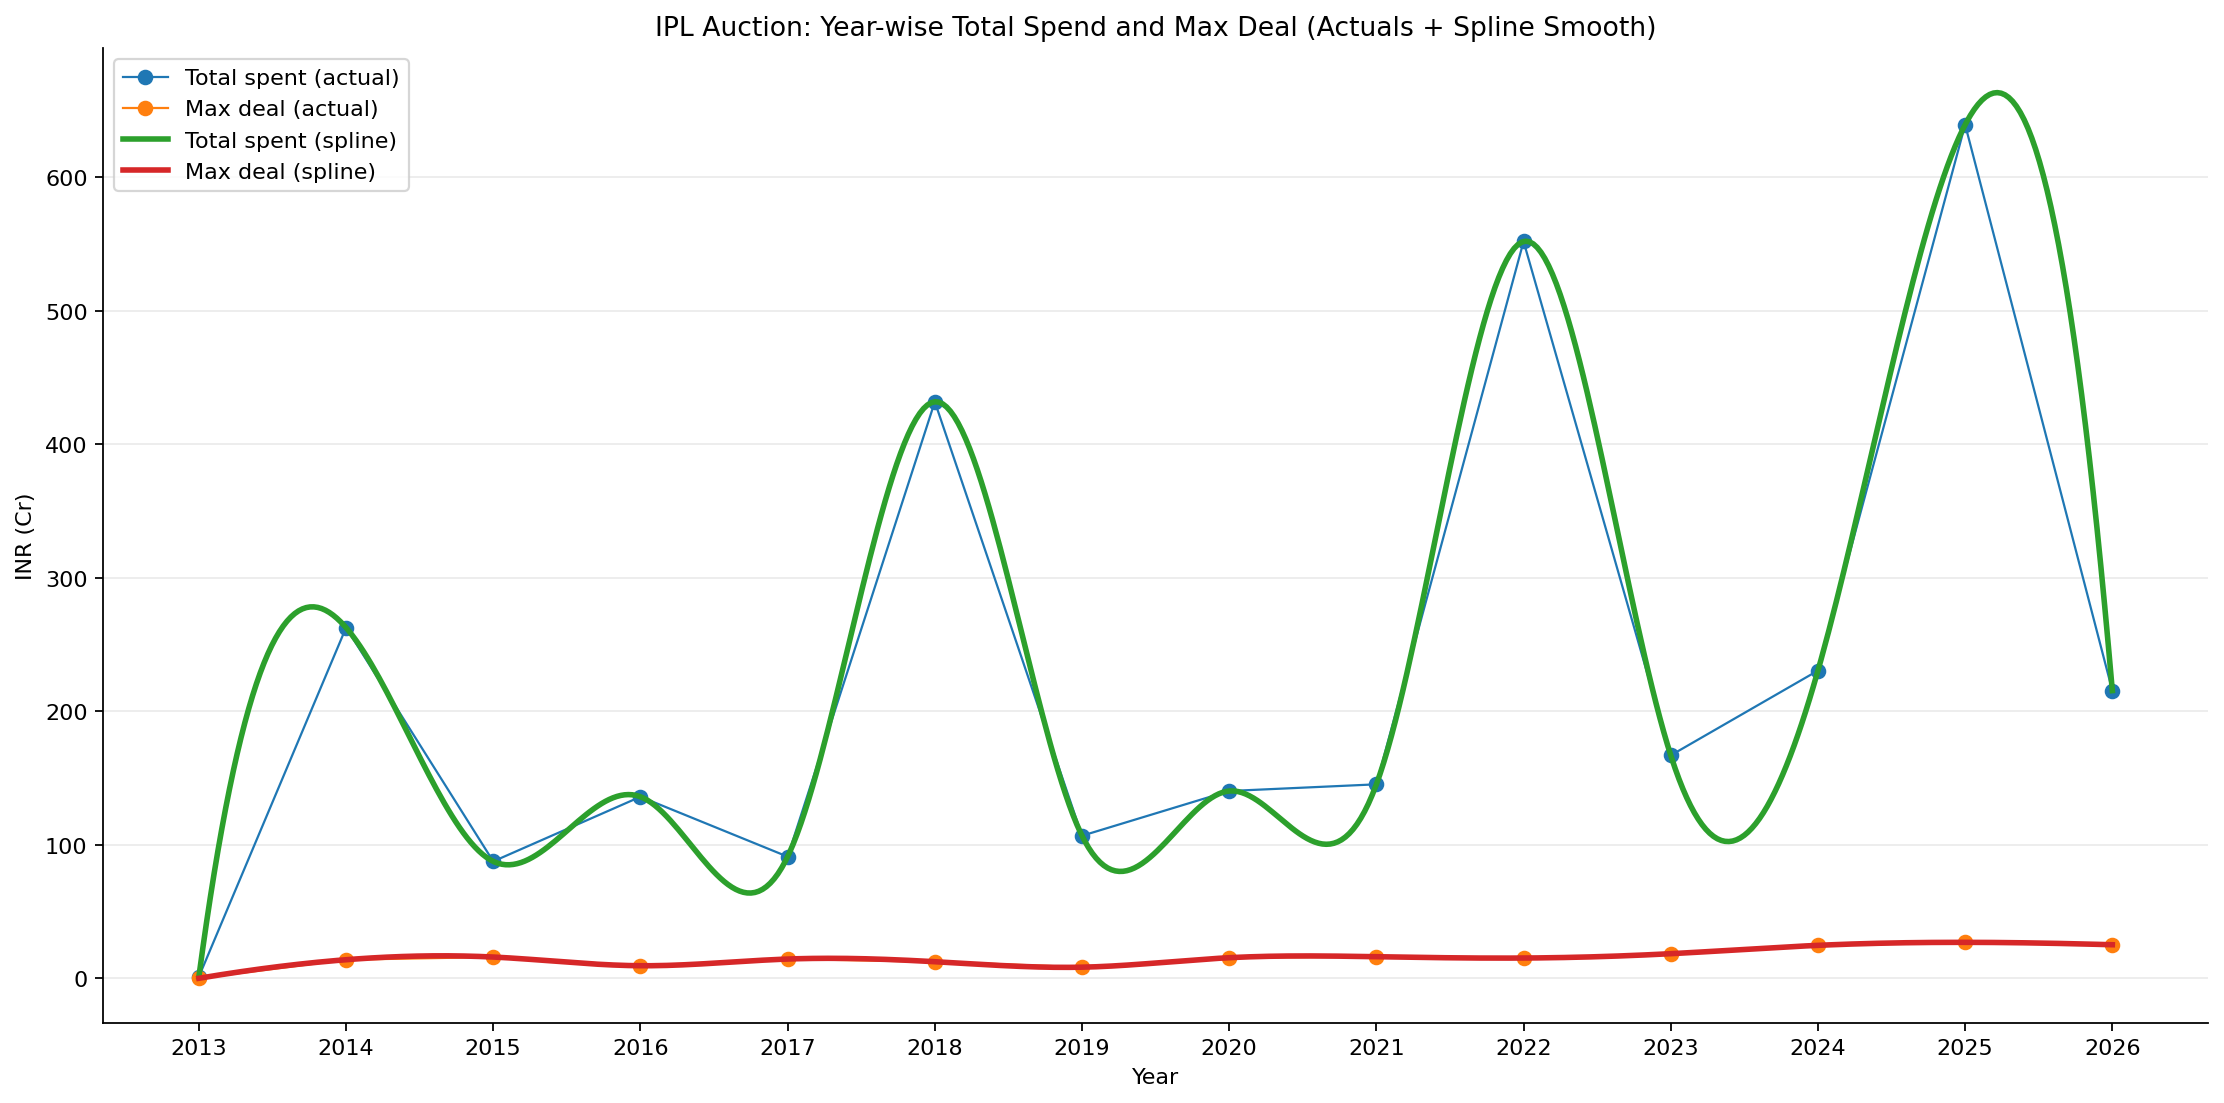

In [7]:
# ----------------------------
# 4) Plot (actual points + smooth lines)
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 7), dpi=160)

# Actual points (markers) + thin straight segments (optional)
ax.plot(years, total_spent_cr, marker="o", linewidth=1.0, label="Total spent (actual)")
ax.plot(years, max_spent_cr, marker="o", linewidth=1.0, label="Max deal (actual)")

# Smooth curves
ax.plot(years_s_total, total_smooth_cr, linewidth=2.5, label="Total spent (spline)")
ax.plot(years_s_max, max_smooth_cr, linewidth=2.5, label="Max deal (spline)")

ax.set_title("IPL Auction: Year-wise Total Spend and Max Deal (Actuals + Spline Smooth)")
ax.set_xlabel("Year")
ax.set_ylabel("INR (Cr)")
ax.set_xticks(years.astype(int))
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()